# Практична робота 3.5
## Аналіз набору даних з Kaggle

**Мета роботи:** навчитися завантажувати, очищати, трансформувати та аналізувати
реальні набори даних з платформи Kaggle, використовуючи методи трансформації
та декомпозиції даних для моделювання.

### 1. Вибір набору даних з Kaggle

Обрано набір даних про пости в соціальній мережі Reddit, присвячені війні в Україні
(тематика — військова аналітика).

Файл: `archive/original_data.csv` — 10 000 записів, 12 стовпців.

Основні стовпці:

| Стовпець | Опис |
|---|---|
| `subreddit` | спільнота, де опубліковано пост (категоріальна) |
| `title` | заголовок поста |
| `selftext` | текст поста |
| `author` | автор |
| `ups` | кількість апвотів (популярність) |
| `upvote_ratio` | частка позитивних голосів |
| `num_comments` | кількість коментарів |
| `created_utc` | час публікації |

### 2. Завантаження та попередній перегляд даних

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Завантаження даних
df = pd.read_csv('archive/original_data.csv')

# Перегляд перших рядків
print(df.head())

   Unnamed: 0           subreddit  \
0           0  NonCredibleDefense   
1           1             ukraine   
2           2   UkrainianConflict   
3           3              europe   
4           4              europe   

                                            selftext author_fullname  \
0                                                NaN     t2_4dfoopu9   
1                                                NaN     t2_3so708z2   
2                                                NaN     t2_p5qo3hyf   
3  \r\nThis megathread is meant for discussion of...        t2_ojkhp   
4  This megathread is meant for discussion of the...        t2_ojkhp   

                                               title  upvote_ratio    ups  \
0  Damn...we blinked and missed the T-34 stage of...          0.79  10398   
1  Finnish🇫🇮 volunteer sends greetings home from ...          0.90   2100   
2  Massive #HIMARS strikes 60km from the front in...          0.79    834   
3                     War in Ukraine

In [2]:
# Огляд інформації про набір даних
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       10000 non-null  int64  
 1   subreddit        10000 non-null  str    
 2   selftext         4137 non-null   str    
 3   author_fullname  10000 non-null  str    
 4   title            10000 non-null  str    
 5   upvote_ratio     10000 non-null  float64
 6   ups              10000 non-null  int64  
 7   created          10000 non-null  int64  
 8   created_utc      10000 non-null  int64  
 9   num_comments     10000 non-null  int64  
 10  author           10000 non-null  str    
 11  id               10000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 937.6 KB
None


In [3]:
print('Кількість рядків і стовпців:', df.shape)

Кількість рядків і стовпців: (10000, 12)


### 3. Очищення даних

In [4]:
# Перевірка на пропущені значення
print(df.isnull().sum())

Unnamed: 0            0
subreddit             0
selftext           5863
author_fullname       0
title                 0
upvote_ratio          0
ups                   0
created               0
created_utc           0
num_comments          0
author                0
id                    0
dtype: int64


In [5]:
# Стовпець 'Unnamed: 0' - це службовий номер рядка, він не потрібен
df = df.drop(columns=['Unnamed: 0'])

# Заповнення пропущених значень
df['selftext'] = df['selftext'].fillna('немає тексту')
df['author'] = df['author'].fillna('невідомий')
df['author_fullname'] = df['author_fullname'].fillna('невідомий')

print('Пропущених значень залишилось:', df.isnull().sum().sum())

Пропущених значень залишилось: 0


In [6]:
# Видалення дублікатів
print('Рядків до видалення дублікатів:', len(df))
df = df.drop_duplicates()
print('Рядків після видалення дублікатів:', len(df))

Рядків до видалення дублікатів: 10000
Рядків після видалення дублікатів: 1123


In [7]:
# Перетворення категоріальної змінної на числову
df['subreddit_code'] = df['subreddit'].astype('category').cat.codes

print(df[['subreddit', 'subreddit_code']].head())

            subreddit  subreddit_code
0  NonCredibleDefense               7
1             ukraine              41
2   UkrainianConflict              18
3              europe              28
4              europe              28


### 4. Трансформація даних

In [8]:
from sklearn.preprocessing import MinMaxScaler

# Нормалізація числових змінних
scaler = MinMaxScaler()
df[['ups_scaled', 'comments_scaled']] = scaler.fit_transform(df[['ups', 'num_comments']])

print(df[['ups', 'ups_scaled', 'num_comments', 'comments_scaled']].head())

     ups  ups_scaled  num_comments  comments_scaled
0  10398    0.999423           738         0.077488
1   2100    0.201845            57         0.005985
2    834    0.080161            41         0.004305
3    578    0.055556          8232         0.864343
4    424    0.040754          9524         1.000000


In [9]:
# One-Hot Encoding для категоріальної змінної
df_transformed = pd.get_dummies(df, columns=['subreddit'], dtype=int)

print('Стовпців було:', df.shape[1], ' стало:', df_transformed.shape[1])

Стовпців було: 14  стало: 60


### 5. Декомпозиція набору даних

In [10]:
from sklearn.model_selection import train_test_split

# Поділ на навчальну та тестову вибірки (80% / 20%)
train_set, test_set = train_test_split(df_transformed, test_size=0.2, random_state=42)

print('Навчальна вибірка:', train_set.shape)
print('Тестова вибірка:', test_set.shape)

Навчальна вибірка: (898, 60)
Тестова вибірка: (225, 60)


In [11]:
# Кореляційна матриця для кількісних змінних
numbers = df[['ups', 'num_comments', 'upvote_ratio', 'subreddit_code']]
correlation_matrix = numbers.corr()

print(correlation_matrix)

                     ups  num_comments  upvote_ratio  subreddit_code
ups             1.000000      0.083572      0.143794       -0.162518
num_comments    0.083572      1.000000      0.159954        0.140910
upvote_ratio    0.143794      0.159954      1.000000       -0.000869
subreddit_code -0.162518      0.140910     -0.000869        1.000000


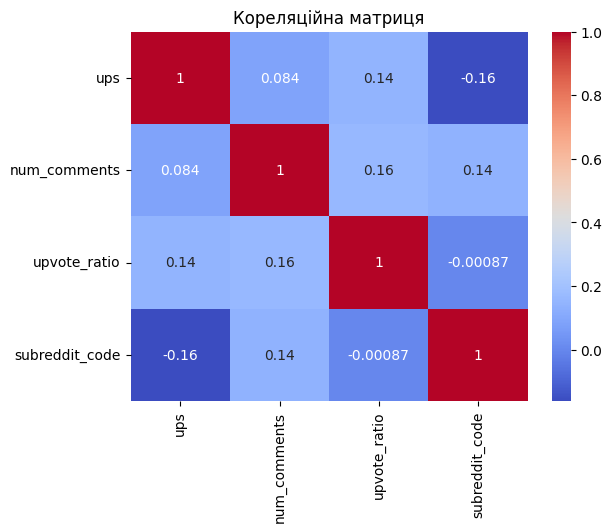

In [12]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Кореляційна матриця')
plt.show()

### 6. Описова статистика та візуалізація

In [13]:
# Описова статистика
print(df[['ups', 'num_comments', 'upvote_ratio']].describe())

                ups  num_comments  upvote_ratio
count   1123.000000   1123.000000   1123.000000
mean     202.435441    610.777382      0.682600
std     1130.300957   2022.722627      0.133363
min        0.000000      0.000000      0.300000
25%        5.000000      1.000000      0.600000
50%        8.000000     31.000000      0.680000
75%       35.000000     40.000000      0.770000
max    10404.000000   9524.000000      0.900000


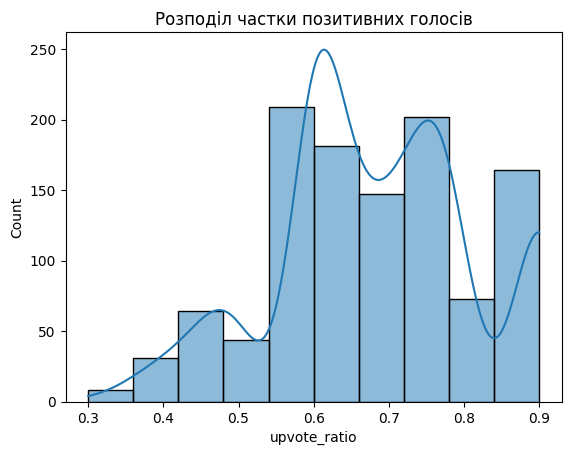

In [14]:
# Гістограма для кількісної змінної
sns.histplot(df['upvote_ratio'], bins=10, kde=True)
plt.title('Розподіл частки позитивних голосів')
plt.show()

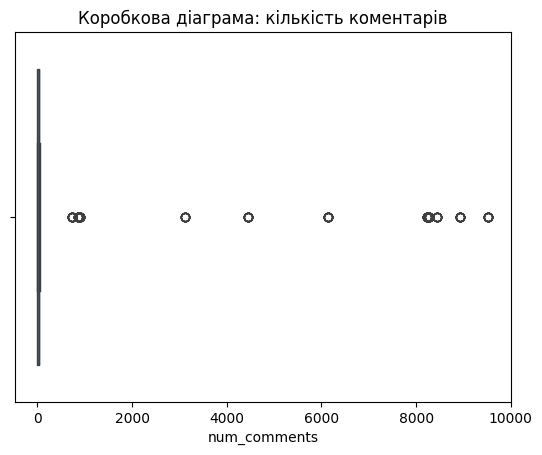

In [15]:
# Коробкова діаграма
sns.boxplot(x=df['num_comments'])
plt.title('Коробкова діаграма: кількість коментарів')
plt.show()

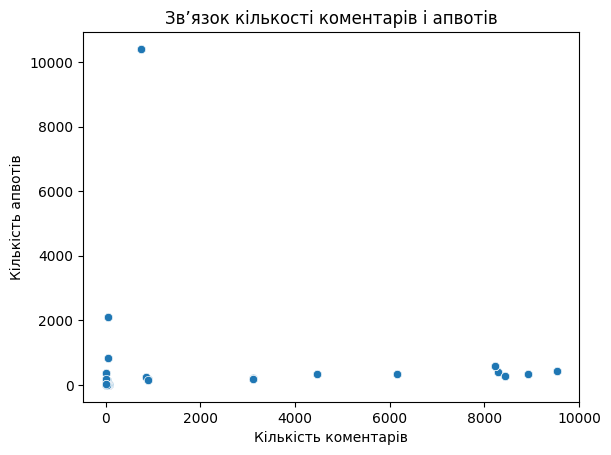

In [16]:
# Діаграма розсіювання
sns.scatterplot(x=df['num_comments'], y=df['ups'])
plt.title('Звʼязок кількості коментарів і апвотів')
plt.xlabel('Кількість коментарів')
plt.ylabel('Кількість апвотів')
plt.show()

### 7. Побудова моделі

Будуємо лінійну регресію: прогнозуємо кількість апвотів (`ups`)
за кількістю коментарів та часткою позитивних голосів.

In [17]:
from sklearn.linear_model import LinearRegression

features = ['num_comments', 'upvote_ratio']
target = 'ups'

# Навчання моделі
model = LinearRegression()
model.fit(train_set[features], train_set[target])

# Прогноз на тестовій вибірці
predictions = model.predict(test_set[features])
print(predictions[:10])

[258.7381802  325.05152588 154.41780693  90.12258806 240.25861669
 258.7381802  202.89798608 107.03263756 362.91255216 -14.85479107]


In [18]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(test_set[target], predictions)
mae = mean_absolute_error(test_set[target], predictions)

print('R2 =', round(r2, 3))
print('Середня абсолютна помилка =', round(mae, 1))
print('Коефіцієнти моделі:', model.coef_.round(3))

R2 = 0.023
Середня абсолютна помилка = 340.3
Коефіцієнти моделі: [3.70000e-02 9.47703e+02]


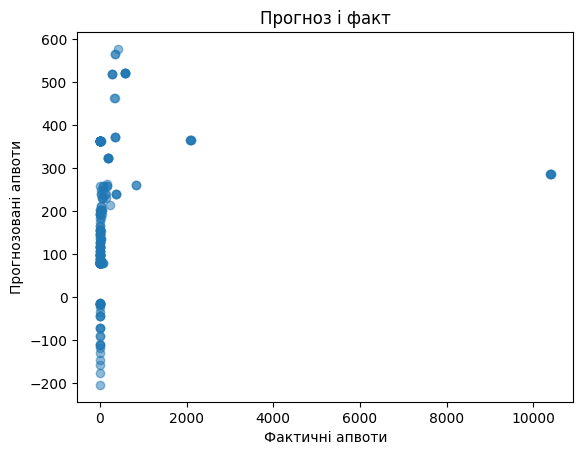

In [19]:
plt.scatter(test_set[target], predictions, alpha=0.5)
plt.xlabel('Фактичні апвоти')
plt.ylabel('Прогнозовані апвоти')
plt.title('Прогноз і факт')
plt.show()

### 8. Звітування. Висновки

**Опис набору даних.** Використано набір із 10 000 записів про пости Reddit
на військову тематику. Кожен запис містить спільноту, автора, заголовок,
текст поста, час публікації, кількість апвотів, коментарів
та частку позитивних голосів.

**Очищення та трансформація.** Видалено службовий стовпець `Unnamed: 0`.
Пропуски були лише у трьох текстових стовпцях (найбільше — у `selftext`,
бо багато постів є просто посиланнями або картинками), їх заповнено
текстовою заміткою. Після видалення дублікатів залишилось 1 123 записи
з 10 000 — тобто майже 90 % рядків були повторами.
Категоріальну змінну `subreddit` перетворено на числову двома способами:
через `cat.codes` та One-Hot Encoding. Числові змінні `ups` і `num_comments`
нормалізовано методом MinMax.

**Аналіз кореляції.** Усі зв'язки виявились слабкими:
`ups` — `upvote_ratio` дає 0.14, `ups` — `num_comments` лише 0.08.
Кореляція з `subreddit_code` (-0.16) до уваги не береться, бо це просто
порядковий номер спільноти, а не величина.

**Візуалізація.** Гістограма показує, що більшість постів мають високу
частку позитивних голосів — 0.9 і вище. Коробкова діаграма демонструє
велику кількість викидів: більшість постів мають мало коментарів,
але окремі набирають їх сотні. Діаграма розсіювання підтверджує, що чіткої
лінійної залежності між коментарями та апвотами немає — точки розкидані.

**Результат моделі.** Лінійна регресія на ознаках `num_comments`
та `upvote_ratio` дала R² = 0.023 і середню абсолютну помилку 340 апвотів.
Це низька точність: модель майже не пояснює популярність поста.
Причина видно на графіках — значення `ups` змінюються від кількох голосів
до понад 10 000, розподіл має довгий «хвіст» із викидів, і проста лінійна
залежність такі дані описати не може.

**Висновок.** У роботі виконано повний цикл роботи з реальними даними:
завантаження, очищення, трансформація, декомпозиція, аналіз та моделювання.
Основний результат — обрані ознаки не дозволяють прогнозувати популярність
поста лінійною моделлю. Щоб покращити прогноз, потрібно додати нові ознаки
(година публікації, довжина заголовка, наявність тексту), прологарифмувати
цільову змінну через великий розкид значень і спробувати нелінійні моделі.